**PHƯƠNG PHÁP: LUẬT KẾT HỢP (Association Rule Mining)**

#  1. Thiết lập môi trường và tải dữ liệu

## Cài đặt thư viện cần thiết

In [2]:
install.packages("tidyverse")
install.packages("arules")
install.packages("arulesViz")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘permute’, ‘zoo’, ‘tweenr’, ‘polyclip’, ‘RcppEigen’, ‘gridExtra’, ‘RcppArmadillo’, ‘ca’, ‘foreach’, ‘gclus’, ‘qap’, ‘registry’, ‘TSP’, ‘vegan’, ‘lmtest’, ‘ggforce’, ‘ggrepel’, ‘viridis’, ‘tidygraph’, ‘graphlayouts’, ‘crosstalk’, ‘lazyeval’, ‘seriation’, ‘vcd’, ‘igraph’, ‘scatterplot3d’, ‘ggraph’, ‘DT’, ‘plotly’, ‘visNetwork’




In [3]:
library(tidyverse)

library(arules)
library(arulesViz)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘arules’


The following object is masked from ‘package:dplyr’:

    recode


The following objects are masked from ‘package:base’:

    abbreviate, write




## Tải và đọc dữ liệu

In [4]:
#read data
market<-read.transactions(
  file='groceries.csv',
  sep=',',
  format='basket',
  rm.duplicates=TRUE)
market

transactions in sparse format with
 9835 transactions (rows) and
 169 items (columns)

In [5]:
summary(market)

transactions as itemMatrix in sparse format with
 9835 rows (elements/itemsets/transactions) and
 169 columns (items) and a density of 0.02609146 

most frequent items:
      whole milk other vegetables       rolls/buns             soda 
            2513             1903             1809             1715 
          yogurt          (Other) 
            1372            34055 

element (itemset/transaction) length distribution:
sizes
   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15   16 
2159 1643 1299 1005  855  645  545  438  350  246  182  117   78   77   55   46 
  17   18   19   20   21   22   23   24   26   27   28   29   32 
  29   14   14    9   11    4    6    1    1    1    1    3    1 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   2.000   3.000   4.409   6.000  32.000 

includes extended item information - examples:
            labels
1 abrasive cleaner
2 artif. sweetener
3   baby cosmetics

#  2. Chuẩn bị và khám phá dữ liệu

In [6]:
market %>% head(n=5)%>% inspect()

    items                      
[1] {citrus fruit,             
     margarine,                
     ready soups,              
     semi-finished bread}      
[2] {coffee,                   
     tropical fruit,           
     yogurt}                   
[3] {whole milk}               
[4] {cream cheese,             
     meat spreads,             
     pip fruit,                
     yogurt}                   
[5] {condensed milk,           
     long life bakery product, 
     other vegetables,         
     whole milk}               


abrasive cleaner          artif. sweetener            baby cosmetics 
                       35                        32                         6 
                baby food                      bags             baking powder 
                        1                         4                       174 
         bathroom cleaner                      beef                   berries 
                       27                       516                       327 
                beverages              bottled beer             bottled water 
                      256                       792                      1087 
                   brandy               brown bread                    butter 
                       41                       638                       545 
              butter milk                  cake bar                   candles 
                      275                       130                        88 
                    candy               canned beer               canned fish 
                      294                       764                       148 
             canned fruit         canned vegetables                  cat food 
                       32                       106                       229 
                  cereals               chewing gum                   chicken 
                       56                       207                       422 
                chocolate     chocolate marshmallow              citrus fruit 
                      488                        89                       814 
                  cleaner           cling film/bags              cocoa drinks 
                       50                       112                        22 
                   coffee            condensed milk         cooking chocolate 
                      571                       101                        25 
                 cookware                     cream              cream cheese 
                       27                        13                       390 
                     curd               curd cheese               decalcifier 
                      524                        50                        15 
              dental care                   dessert                 detergent 
                       57                       365                       189 
             dish cleaner                    dishes                  dog food 
                      103                       173                        84 
            domestic eggs  female sanitary products         finished products 
                      624                        60                        64 
                     fish                     flour            flower (seeds) 
                       29                       171                       102 
   flower soil/fertilizer               frankfurter            frozen chicken 
                       19                       580                         6 
           frozen dessert               frozen fish             frozen fruits 
                      106                       115                        12 
             frozen meals    frozen potato products         frozen vegetables 
                      279                        83                       473 
    fruit/vegetable juice                    grapes                hair spray 
                      711                       220                        11 
                      ham            hamburger meat               hard cheese 
                      256                       327                       241 
                    herbs                     honey    house keeping products 
                      160                        15                        82 
         hygiene articles                 ice cream            instant coffee 
                      324                       246                        73 
    Instant food products                       jam        

Warning message in brewer.pal(20, "Spectral"):
“n too large, allowed maximum for palette Spectral is 11
Returning the palette you asked for with that many colors
”


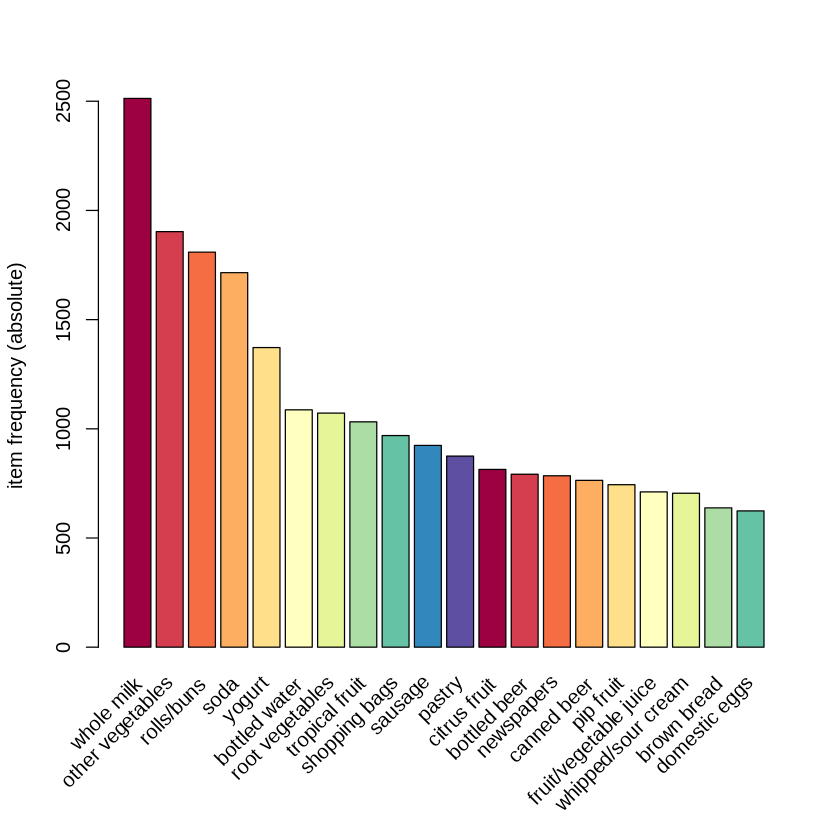

In [7]:
# Plot the frequency of top frequent items
library(RColorBrewer)
itemFrequency(x=market, type= 'absolute')
itemFrequencyPlot(x=market,
                  topN=20,
                  type= 'absolute',
                  horiz= FALSE,
                  col=brewer.pal(20,'Spectral'))

In [8]:
freq_items <- c(itemFrequency(x=market, type= 'absolute'))
freq_items <- data.frame(freq_items)
freq_items

,freq_items
,<int>
abrasive cleaner,35
artif. sweetener,32
baby cosmetics,6
baby food,1
bags,4
baking powder,174
bathroom cleaner,27
beef,516
berries,327


# Mô hình thuật toán

## Apriori algorithm

In [9]:
# Product associations for 0.05% support and confidence of 80%
rule1<- market %>%
  apriori(parameter=list(supp=0.0005,conf=0.8)) %>%
  sort(by='support')

summary(rule1)

rule1 %>% head(n=2)%>% inspect

rule1 %>% tail(n=2)%>% inspect

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5   5e-04      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 4 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[169 item(s), 9835 transaction(s)] done [0.01s].
sorting and recoding items ... [164 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 6 7 done [0.03s].
writing ... [9778 rule(s)] done [0.01s].
creating S4 object  ... done [0.01s].


set of 9778 rules

rule length distribution (lhs + rhs):sizes
   3    4    5    6    7 
 271 3192 4559 1597  159 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.000   4.000   5.000   4.814   5.000   7.000 

summary of quality measures:
    support            confidence        coverage              lift       
 Min.   :0.0005084   Min.   :0.8000   Min.   :0.0005084   Min.   : 3.131  
 1st Qu.:0.0005084   1st Qu.:0.8333   1st Qu.:0.0005084   1st Qu.: 3.914  
 Median :0.0005084   Median :0.8571   Median :0.0006101   Median : 4.307  
 Mean   :0.0006044   Mean   :0.9016   Mean   :0.0006774   Mean   : 5.665  
 3rd Qu.:0.0006101   3rd Qu.:1.0000   3rd Qu.:0.0007117   3rd Qu.: 6.144  
 Max.   :0.0031520   Max.   :1.0000   Max.   :0.0035587   Max.   :79.571  
     count       
 Min.   : 5.000  
 1st Qu.: 5.000  
 Median : 5.000  
 Mean   : 5.944  
 3rd Qu.: 6.000  
 Max.   :31.000  

mining info:
 data ntransactions support confidence
    .          9835   5e-04        0.8
              

    lhs                   rhs                    support confidence    coverage     lift count
[1] {citrus fruit,                                                                            
     root vegetables,                                                                         
     tropical fruit,                                                                          
     whole milk}       => {other vegetables} 0.003152008  0.8857143 0.003558719 4.577509    31
[2] {curd,                                                                                    
     domestic eggs,                                                                           
     other vegetables} => {whole milk}       0.002846975  0.8235294 0.003457041 3.223005    28
    lhs                    rhs                   support confidence     coverage     lift count
[1] {bottled water,                                                                            
     other vegetables,                          

In [10]:
rule1<-rule1%>%sort(by="lift")
rule1 %>% head(n=5)%>% inspect

    lhs                     rhs                 support confidence     coverage     lift count
[1] {hamburger meat,                                                                          
     herbs,                                                                                   
     soda}               => {dish cleaner} 0.0005083884  0.8333333 0.0006100661 79.57120     5
[2] {brown bread,                                                                             
     pip fruit,                                                                               
     sliced cheese}      => {frozen fish}  0.0005083884  0.8333333 0.0006100661 71.26812     5
[3] {ham,                                                                                     
     other vegetables,                                                                        
     sliced cheese,                                                                           
     whipped/sour cream} => {soft cheese}  0.00050

In [11]:
#plot(rule1,engine="htmlwidget")
#plot(rule1, method="two-key", engine="htmlwidget")
plot(rule1, method="graph", engine="htmlwidget")

Warning message:
“Too many rules supplied. Only plotting the best 100 using ‘lift’ (change control parameter max if needed).”


HTML widgets cannot be represented in plain text (need html)

In [12]:
# Product associations for 0.1% support and confidence of 80%
rule2<- market %>%
  apriori(parameter=list(supp=0.001,conf=0.8)) %>%
  sort(by='confidence')
summary(rule1)

rule2 %>% head(n=5)%>% inspect

rule2 %>% tail(n=5)%>% inspect

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5   0.001      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 9 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[169 item(s), 9835 transaction(s)] done [0.01s].
sorting and recoding items ... [157 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 6 done [0.01s].
writing ... [410 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


set of 9778 rules

rule length distribution (lhs + rhs):sizes
   3    4    5    6    7 
 271 3192 4559 1597  159 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.000   4.000   5.000   4.814   5.000   7.000 

summary of quality measures:
    support            confidence        coverage              lift       
 Min.   :0.0005084   Min.   :0.8000   Min.   :0.0005084   Min.   : 3.131  
 1st Qu.:0.0005084   1st Qu.:0.8333   1st Qu.:0.0005084   1st Qu.: 3.914  
 Median :0.0005084   Median :0.8571   Median :0.0006101   Median : 4.307  
 Mean   :0.0006044   Mean   :0.9016   Mean   :0.0006774   Mean   : 5.665  
 3rd Qu.:0.0006101   3rd Qu.:1.0000   3rd Qu.:0.0007117   3rd Qu.: 6.144  
 Max.   :0.0031520   Max.   :1.0000   Max.   :0.0035587   Max.   :79.571  
     count       
 Min.   : 5.000  
 1st Qu.: 5.000  
 Median : 5.000  
 Mean   : 5.944  
 3rd Qu.: 6.000  
 Max.   :31.000  

mining info:
 data ntransactions support confidence
    .          9835   5e-04        0.8
              

    lhs                     rhs              support confidence    coverage     lift count
[1] {rice,                                                                                
     sugar}              => {whole milk} 0.001220132          1 0.001220132 3.913649    12
[2] {canned fish,                                                                         
     hygiene articles}   => {whole milk} 0.001118454          1 0.001118454 3.913649    11
[3] {butter,                                                                              
     rice,                                                                                
     root vegetables}    => {whole milk} 0.001016777          1 0.001016777 3.913649    10
[4] {flour,                                                                               
     root vegetables,                                                                     
     whipped/sour cream} => {whole milk} 0.001728521          1 0.001728521 3.913649    17

In [14]:
#plot(rule2,engine="htmlwidget")
#plot(rule2, method="two-key", engine="htmlwidget")
plot(rule2, method="graph", engine="htmlwidget")


Warning message:
“Too many rules supplied. Only plotting the best 100 using ‘lift’ (change control parameter max if needed).”


HTML widgets cannot be represented in plain text (need html)

In [15]:
# Product associations for 0.3% support and confidence of 70%
rule3<- market %>%
  apriori(parameter=list(supp=0.003,conf=0.7)) %>%
  sort(by='support')
summary(rule3)

rule3 %>% head(n=5)%>% inspect

rule3 %>% tail(n=5)%>% inspect

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.7    0.1    1 none FALSE            TRUE       5   0.003      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 29 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[169 item(s), 9835 transaction(s)] done [0.01s].
sorting and recoding items ... [136 item(s)] done [0.00s].
creating transaction tree ... done [0.01s].
checking subsets of size 1 2 3 4 5 done [0.01s].
writing ... [19 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].


set of 19 rules

rule length distribution (lhs + rhs):sizes
3 4 5 
7 9 3 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.000   3.000   4.000   3.789   4.000   5.000 

summary of quality measures:
    support           confidence        coverage             lift      
 Min.   :0.003050   Min.   :0.7000   Min.   :0.003559   Min.   :2.740  
 1st Qu.:0.003203   1st Qu.:0.7047   1st Qu.:0.004525   1st Qu.:2.758  
 Median :0.003559   Median :0.7164   Median :0.004982   Median :2.804  
 Mean   :0.003767   Mean   :0.7373   Mean   :0.005143   Mean   :3.044  
 3rd Qu.:0.004169   3rd Qu.:0.7500   3rd Qu.:0.005592   3rd Qu.:2.984  
 Max.   :0.005694   Max.   :0.8857   Max.   :0.008134   Max.   :4.578  
     count      
 Min.   :30.00  
 1st Qu.:31.50  
 Median :35.00  
 Mean   :37.05  
 3rd Qu.:41.00  
 Max.   :56.00  

mining info:
 data ntransactions support confidence
    .          9835   0.003        0.7
                                                          call
 apriori(data = ., 

    lhs                      rhs                    support confidence    coverage     lift count
[1] {root vegetables,                                                                            
     tropical fruit,                                                                             
     yogurt}              => {whole milk}       0.005693950  0.7000000 0.008134215 2.739554    56
[2] {butter,                                                                                     
     curd}                => {whole milk}       0.004880529  0.7164179 0.006812405 2.803808    48
[3] {curd,                                                                                       
     domestic eggs}       => {whole milk}       0.004778851  0.7343750 0.006507372 2.874086    47
[4] {citrus fruit,                                                                               
     root vegetables,                                                                            
     tropical fruit}

In [19]:
 #plot(rule3,engine="htmlwidget")
 #plot(rule3, method="two-key", engine="htmlwidget")
plot(rule3, method="graph", engine="htmlwidget")

HTML widgets cannot be represented in plain text (need html)

In [36]:
# Assuming you have already generated the rules
# Each row of the rules data frame represents a rule
# The "support" column contains the support value for each rule

# Extract the support values from the rules data frame
#support_values <- rules$support

# Calculate the mean support value
#mean_support <- mean(support_values)

# Print the mean support value
#print(paste("Mean Support: ", mean_support))

## Eclat algorithm

In [20]:
# Applying Eclat algorithm
eclat_r <- eclat(market, parameter = list(support = 0.0005, minlen = 2))

# Display summary of the Eclat results
summary(eclat_r)

# View the generated frequent itemsets
eclat_r %>% head(n=5)%>% inspect

Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
    FALSE   5e-04      2     10 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 4 

create itemset ... 
set transactions ...[169 item(s), 9835 transaction(s)] done [0.01s].
sorting and recoding items ... [164 item(s)] done [0.00s].
creating sparse bit matrix ... [164 row(s), 9835 column(s)] done [0.00s].
writing  ... [49416 set(s)] done [0.06s].
Creating S4 object  ... done [0.01s].


set of 49416 itemsets

most frequent items:
      whole milk other vegetables           yogurt  root vegetables 
           14983            13438            10113             8407 
  tropical fruit          (Other) 
            7853           121752 

element (itemset/transaction) length distribution:sizes
    2     3     4     5     6     7 
 4782 19226 18597  5988   785    38 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.000   3.000   4.000   3.573   4.000   7.000 

summary of quality measures:
    support              count      
 Min.   :0.0005084   Min.   :  5.0  
 1st Qu.:0.0005084   1st Qu.:  5.0  
 Median :0.0007117   Median :  7.0  
 Mean   :0.0010674   Mean   : 10.5  
 3rd Qu.:0.0010168   3rd Qu.: 10.0  
 Max.   :0.0748348   Max.   :736.0  

includes transaction ID lists: FALSE 

mining info:
   data ntransactions support
 market          9835   5e-04
                                                                call
 eclat(data = market, parameter = list(support 

    items                                       support      count
[1] {other vegetables, salad dressing}          0.0005083884 5    
[2] {butter, rubbing alcohol, whole milk}       0.0005083884 5    
[3] {citrus fruit, rubbing alcohol, whole milk} 0.0005083884 5    
[4] {rubbing alcohol, whole milk}               0.0006100661 6    
[5] {citrus fruit, rubbing alcohol}             0.0005083884 5    


In [21]:
# Product associations for 0.1% support
eclat_r1 <- market %>% eclat(parameter = list(support = 0.001, minlen = 2))%>%sort(by='support')

# Display summary of the Eclat results
summary(eclat_r1)

# View the generated frequent itemsets
eclat_r1 %>% head(n=5)%>% inspect

Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
    FALSE   0.001      2     10 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 9 

create itemset ... 
set transactions ...[169 item(s), 9835 transaction(s)] done [0.01s].
sorting and recoding items ... [157 item(s)] done [0.00s].
creating sparse bit matrix ... [157 row(s), 9835 column(s)] done [0.00s].
writing  ... [13335 set(s)] done [0.04s].
Creating S4 object  ... done [0.00s].


set of 13335 itemsets

most frequent items:
      whole milk other vegetables           yogurt  root vegetables 
            3764             3341             2401             1958 
  tropical fruit          (Other) 
            1796            27683 

element (itemset/transaction) length distribution:sizes
   2    3    4    5    6 
2981 6831 3137  376   10 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.00    3.00    3.00    3.07    4.00    6.00 

summary of quality measures:
    support             count       
 Min.   :0.001017   Min.   : 10.00  
 1st Qu.:0.001118   1st Qu.: 11.00  
 Median :0.001423   Median : 14.00  
 Mean   :0.002259   Mean   : 22.22  
 3rd Qu.:0.002237   3rd Qu.: 22.00  
 Max.   :0.074835   Max.   :736.00  

includes transaction ID lists: FALSE 

mining info:
 data ntransactions support
    .          9835   0.001
                                                           call
 eclat(data = ., parameter = list(support = 0.001, minlen = 2))

    items                               support    count
[1] {other vegetables, whole milk}      0.07483477 736  
[2] {rolls/buns, whole milk}            0.05663447 557  
[3] {whole milk, yogurt}                0.05602440 551  
[4] {root vegetables, whole milk}       0.04890696 481  
[5] {other vegetables, root vegetables} 0.04738180 466  


In [22]:
# # Product associations for 0.3% support
eclat_r2 <- market %>% eclat(parameter = list(support = 0.003, minlen = 3))%>%sort(by='support')

# Display summary of the Eclat results
summary(eclat_r2)

# View the generated frequent itemsets
eclat_r2 %>% head(n=5)%>% inspect

Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
    FALSE   0.003      3     10 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 29 

create itemset ... 
set transactions ...[169 item(s), 9835 transaction(s)] done [0.01s].
sorting and recoding items ... [136 item(s)] done [0.00s].
creating sparse bit matrix ... [136 row(s), 9835 column(s)] done [0.00s].
writing  ... [950 set(s)] done [0.03s].
Creating S4 object  ... done [0.00s].


set of 950 itemsets

most frequent items:
      whole milk other vegetables           yogurt  root vegetables 
             461              379              243              183 
      rolls/buns          (Other) 
             168             1518 

element (itemset/transaction) length distribution:sizes
  3   4   5 
850  98   2 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.000   3.000   3.000   3.107   3.000   5.000 

summary of quality measures:
    support             count       
 Min.   :0.003050   Min.   : 30.00  
 1st Qu.:0.003355   1st Qu.: 33.00  
 Median :0.003965   Median : 39.00  
 Mean   :0.004773   Mean   : 46.94  
 3rd Qu.:0.005287   3rd Qu.: 52.00  
 Max.   :0.023183   Max.   :228.00  

includes transaction ID lists: FALSE 

mining info:
 data ntransactions support
    .          9835   0.003
                                                           call
 eclat(data = ., parameter = list(support = 0.003, minlen = 3))

    items                                           support    count
[1] {other vegetables, root vegetables, whole milk} 0.02318251 228  
[2] {other vegetables, whole milk, yogurt}          0.02226741 219  
[3] {other vegetables, rolls/buns, whole milk}      0.01789527 176  
[4] {other vegetables, tropical fruit, whole milk}  0.01708185 168  
[5] {rolls/buns, whole milk, yogurt}                0.01555669 153  


In [24]:
install.packages("htmlwidgets")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



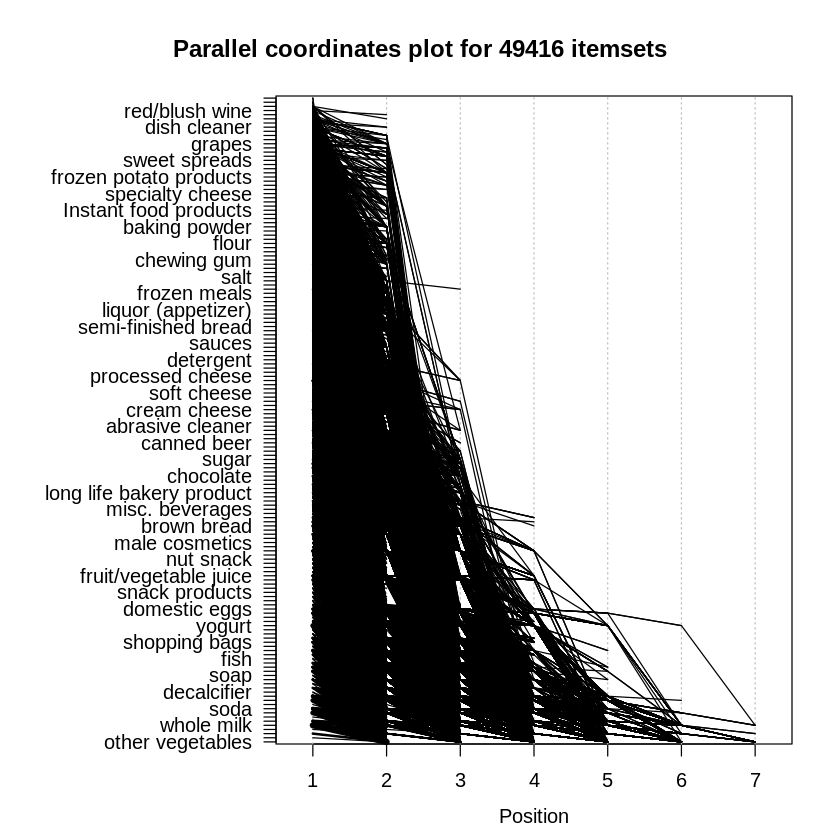

In [23]:
#plot(eclat_r, method = "graph")
#plot(eclat_r,engine="htmlwidget")
plot(eclat_r, method="paracoord")

In [25]:
#plot(eclat_r1, method = "graph")
plot(eclat_r1,engine="htmlwidget")
plot(eclat_r1, method="paracoord")

Output hidden; open in https://colab.research.google.com to view.

In [26]:
#plot(eclat_r2, method = "graph")
plot(eclat_r2,engine="htmlwidget")
plot(eclat_r2, method="paracoord")

Output hidden; open in https://colab.research.google.com to view.

Result analysis of eclat algorithm

In [27]:
# List functions in the arules package

ls("package:arules")

[1] "%ain%"                  "%in%"                   "%oin%"                 
 [4] "%pin%"                  "abbreviate"             "addAggregate"          
 [7] "addComplement"          "affinity"               "aggregate"             
[10] "apriori"                "coerce"                 "compatible"            
[13] "coverage"               "crossTable"             "DATAFRAME"             
[16] "decode"                 "discretize"             "discretizeDF"          
[19] "dissimilarity"          "duplicated"             "eclat"                 
[22] "encode"                 "filterAggregate"        "fim4r"                 
[25] "generatingItemsets"     "head"                   "hits"                  
[28] "image"                  "info"                   "info<-"                
[31] "initialize"             "inspect"                "interestMeasure"       
[34] "intersect"              "is.closed"              "is.element"            
[37] "is.generator"           "is.maximal"             "is.redundant"          
[40] "is.significant"         "is.subset"              "is.superset"           
[43] "itemFrequency"          "itemFrequencyPlot"      "itemInfo"              
[46] "itemInfo<-"             "itemIntersect"          "itemLabels"            
[49] "itemLabels<-"           "items"                  "items<-"               
[52] "itemSetdiff"            "itemsetInfo"            "itemsetInfo<-"         
[55] "itemsets"               "itemUnion"              "labels"                
[58] "lhs"                    "lhs<-"                  "LIST"                  
[61] "match"                  "merge"                  "nitems"                
[64] "plot.associations"      "plot.itemMatrix"        "predict"               
[67] "quality"                "quality<-"              "random.patterns"       
[70] "random.transactions"    "read.PMML"              "read.transactions"     
[73] "recode"                 "rhs"                    "rhs<-"                 
[76] "ruleInduction"          "rules"                  "sample"                
[79] "setdiff"                "setequal"               "show"                  
[82] "size"                   "sort"                   "subset"                
[85] "summary"                "support"                "supportingTransactions"
[88] "t"                      "tail"                   "tidLists"              
[91] "toLongFormat"           "transactionInfo"        "transactionInfo<-"     
[94] "transactions"           "union"                  "unique"                
[97] "weclat"                 "write"                  "write.PMML"

# So sánh đánh giá mô hình

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5    0.01      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 10 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[159 item(s), 1000 transaction(s)] done [0.00s].
sorting and recoding items ... [89 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 done [0.00s].
writing ... [1 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].
Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
    FALSE    0.01      1     10 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 10 

create itemset ... 
set transactions ...[159

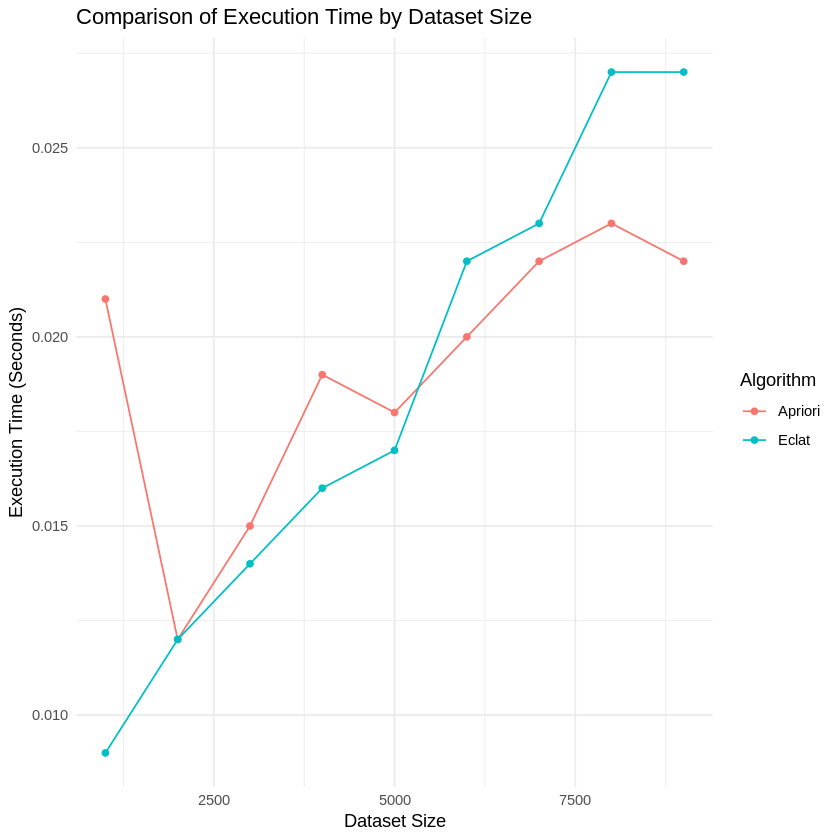

In [28]:
# Load necessary libraries
library(arules)
library(ggplot2)

# Varying dataset sizes
dataset_sizes <- seq(1000, 9835, by = 1000)

# Collect execution times for each algorithm
execution_times <- data.frame(
  Size = numeric(),
  Algorithm = character(),
  Time = numeric()
)

for (size in dataset_sizes) {
  # Generate a sample dataset of 'size' transactions
  transactions <- sample(market, size = size)

  # Measure execution time for Apriori
  runtime_apriori <- system.time({
    apriori_res <- apriori(transactions, parameter = list(support = 0.01))
  })["elapsed"]

  # Measure execution time for FP-Growth
  runtime_eclat <- system.time({
    eclat_res <- eclat(transactions, parameter = list(support = 0.01))
  })["elapsed"]

  # Add times to the data frame
  execution_times <- rbind(
    execution_times,
    data.frame(Size = size, Algorithm = "Apriori", Time = runtime_apriori),
    data.frame(Size = size, Algorithm = "Eclat", Time = runtime_eclat)
  )
}

# Plotting
ggplot(execution_times, aes(x = Size, y = Time, color = Algorithm)) +
  geom_line() +
  geom_point() +
  labs(title = "Comparison of Execution Time by Dataset Size",
       x = "Dataset Size", y = "Execution Time (Seconds)",
       color = "Algorithm") +
  theme_minimal()
print('runtime of apriori:')
print(paste(runtime_apriori))
print('runtime of eclat:')
print(paste(runtime_eclat))

In [29]:
# Define a range of support levels
support_levels <- seq(0.0009, 0.015, by = 0.002)

# Initialize lists to store counts
apriori_counts <- vector("numeric", length = length(support_levels))
eclat_counts <- vector("numeric", length = length(support_levels))

# Calculate counts for different support levels
for (i in seq_along(support_levels)) {
  # Run Apriori algorithm for the current support level
  apriori_res <- apriori(market, parameter = list(support = support_levels[i]), conf=0.5)

  # Run Eclat algorithm for the current support level
  eclat_res <- eclat(market, parameter = list(support = support_levels[i]), minlen = 3)

  # Store the counts
  apriori_counts[i] <- length(apriori_res)
  eclat_counts[i] <- length(eclat_res)
}

Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.5    0.1    1 none FALSE            TRUE       5   9e-04      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 8 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[169 item(s), 9835 transaction(s)] done [0.00s].
sorting and recoding items ... [158 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 6 done [0.01s].
writing ... [7436 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].
Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
    FALSE   9e-04      3     10 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 8 

create itemset ... 
set transactions .

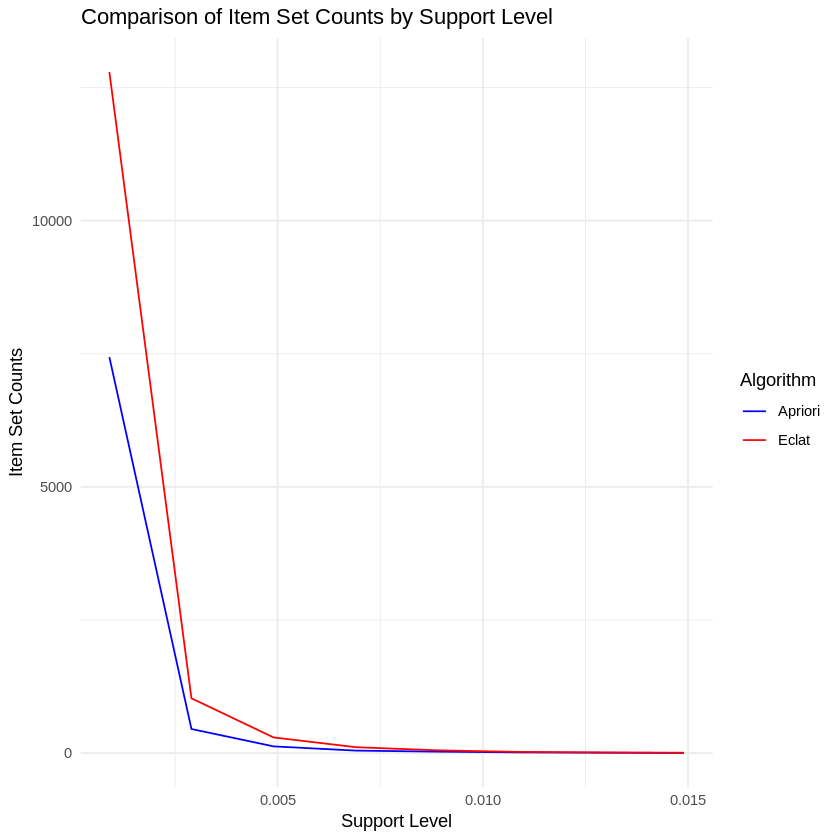

In [30]:
# Creating a data frame for plotting
comparison_data <- data.frame(
  Support = support_levels,
  Apriori_Counts = apriori_counts,
  Eclat_Counts = eclat_counts
)

# Plotting
library(ggplot2)

ggplot(comparison_data, aes(x = Support)) +
  geom_line(aes(y = Apriori_Counts, color = "Apriori")) +
  geom_line(aes(y = Eclat_Counts, color = "Eclat")) +
  labs(
    title = "Comparison of Item Set Counts by Support Level",
    x = "Support Level",
    y = "Item Set Counts",
    color = "Algorithm"
  ) +
  scale_color_manual(values = c("Apriori" = "blue", "Eclat" = "red")) +
  theme_minimal()

In [32]:
install.packages("pryr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘lobstr’




In [33]:
library(pryr)

# Function to estimate memory usage
get_mem <- function(algo) {
  gc()
  mem_used <- object_size(algo)
  return(mem_used)
}

# Run Apriori and Eclat
apriori_alg <- apriori(market, parameter = list(support = 0.001))
eclat_alg <- eclat(market, parameter = list(support = 0.001))


Attaching package: ‘pryr’


The following object is masked from ‘package:arules’:

    inspect


The following object is masked from ‘package:dplyr’:

    where


The following objects are masked from ‘package:purrr’:

    compose, partial




Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.8    0.1    1 none FALSE            TRUE       5   0.001      1
 maxlen target  ext
     10  rules TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 9 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[169 item(s), 9835 transaction(s)] done [0.01s].
sorting and recoding items ... [157 item(s)] done [0.00s].
creating transaction tree ... done [0.00s].
checking subsets of size 1 2 3 4 5 6 done [0.01s].
writing ... [410 rule(s)] done [0.00s].
creating S4 object  ... done [0.00s].
Eclat

parameter specification:
 tidLists support minlen maxlen            target  ext
    FALSE   0.001      1     10 frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 9 

create itemset ... 
set transactions ..

[1] "Memory usage - Apriori: 44416"
[1] "Memory usage - Eclat: 397760"


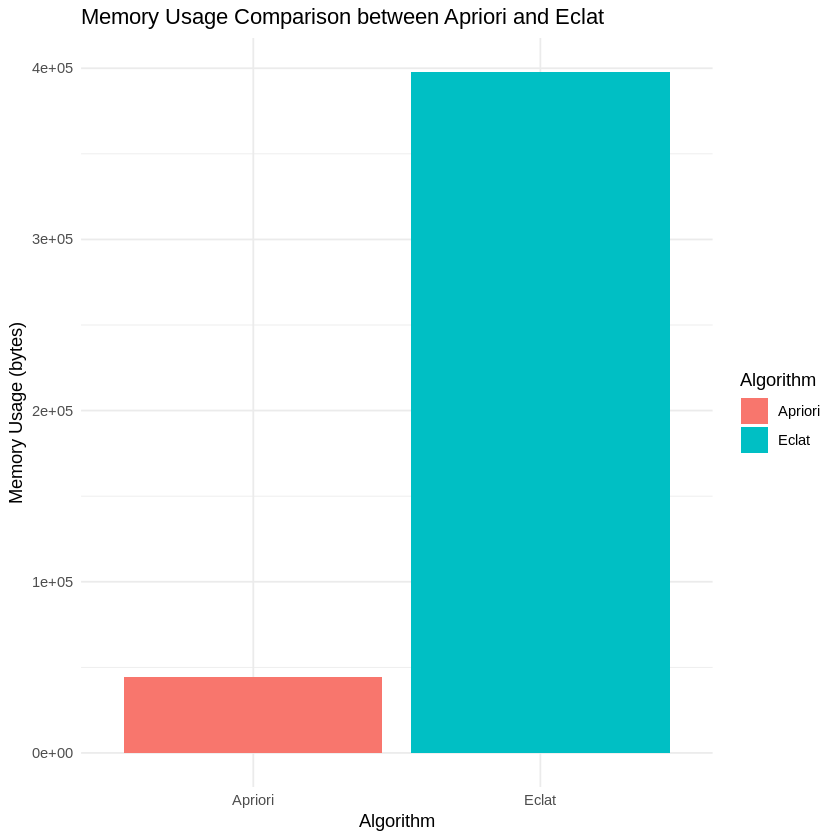

In [34]:
# Calculate memory usage for Apriori and Eclat
mem_apriori <- as.numeric(get_mem(apriori_alg))
mem_eclat <- as.numeric(get_mem(eclat_alg))

# Display memory usage
print(paste("Memory usage - Apriori:", mem_apriori))
print(paste("Memory usage - Eclat:", mem_eclat))

# Create a data frame for plotting
memory_comparison <- data.frame(
  Algorithm = c("Apriori", "Eclat"),
  Memory_Usage = c(mem_apriori, mem_eclat)
)

# Plotting
ggplot(memory_comparison, aes(x = Algorithm, y = Memory_Usage, fill = Algorithm)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Memory Usage Comparison between Apriori and Eclat",
    x = "Algorithm",
    y = "Memory Usage (bytes)",
    fill = "Algorithm"
  ) +
  theme_minimal()